In [1]:
!pip install tensorflow scikit-learn pandas numpy wfdb scipy -q

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import wfdb
import ast
import os
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: []


In [3]:
PATH = '../dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/'

df = pd.read_csv(PATH + 'ptbxl_database.csv', index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(ast.literal_eval)

# these are your tabular features — already in PTB-XL
tabular_cols = ['age', 'sex', 'height', 'weight']
print(df[tabular_cols].describe())
print("Missing:", df[tabular_cols].isnull().sum())

                age           sex       height       weight
count  21748.000000  21837.000000  6983.000000  9429.000000
mean      59.836307      0.478912   166.708292    70.997561
std       16.953125      0.499567    10.864935    15.875146
min        2.000000      0.000000     6.000000     5.000000
25%       50.000000      0.000000   160.000000    60.000000
50%       62.000000      0.000000   166.000000    70.000000
75%       72.000000      1.000000   174.000000    80.000000
max       95.000000      1.000000   209.000000   250.000000
Missing: age          89
sex           0
height    14854
weight    12408
dtype: int64


In [4]:
scp = pd.read_csv(PATH + 'scp_statements.csv', index_col=0)

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

def get_multilabels(scp_dict):
    labels = []
    for sc in SUPERCLASSES:
        has_class = any(
            scp.loc[code, 'diagnostic_class'] == sc
            for code in scp_dict.keys()
            if code in scp.index and
            not pd.isna(scp.loc[code, 'diagnostic_class'])
        )
        labels.append(int(has_class))
    return labels

df['multilabel'] = df.scp_codes.apply(get_multilabels)

In [5]:
def load_ecg(filename):
    record = wfdb.rdrecord(PATH + filename)
    return record.p_signal.astype(np.float32)

def butterworth_bandpass(signal, lowcut=0.5, highcut=40, fs=100, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal, axis=0)

def preprocess_ecg(signal):
    filtered = butterworth_bandpass(signal)
    mean = filtered.mean(axis=0, keepdims=True)
    std = filtered.std(axis=0, keepdims=True) + 1e-8
    return (filtered - mean) / std

print("Loading data...")
X_ecg = []
X_tab = []
y_all = []

for ecg_id, row in df.iterrows():
    try:
        # ECG signal
        signal = preprocess_ecg(load_ecg(row['filename_lr']))
        
        # tabular features — skip if missing
        tab = [row['age'], row['sex'], row['height'], row['weight']]
        if any(pd.isna(v) for v in tab):
            continue
            
        X_ecg.append(signal)
        X_tab.append(tab)
        y_all.append(row['multilabel'])
        
    except:
        pass

X_ecg = np.array(X_ecg)
X_tab = np.array(X_tab, dtype=np.float32)
y_all = np.array(y_all)

print("ECG shape:", X_ecg.shape)    # (N, 1000, 12)
print("Tab shape:", X_tab.shape)    # (N, 4)
print("y shape:  ", y_all.shape)    # (N, 5)

Loading data...
ECG shape: (6680, 1000, 12)
Tab shape: (6680, 4)
y shape:   (6680, 5)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tab = scaler.fit_transform(X_tab)
print("Tabular features scaled")

Tabular features scaled


In [7]:
indices = np.arange(len(X_ecg))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42
)

X_ecg_train, X_ecg_test = X_ecg[train_idx], X_ecg[test_idx]
X_tab_train, X_tab_test = X_tab[train_idx], X_tab[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print("Train:", X_ecg_train.shape, X_tab_train.shape)
print("Test: ", X_ecg_test.shape,  X_tab_test.shape)

Train: (5344, 1000, 12) (5344, 4)
Test:  (1336, 1000, 12) (1336, 4)


In [ ]:
model_path = os.path.normpath("../models/ecg_best.keras")

ecg_embedder = tf.keras.models.load_model(model_path)
ecg_embedder.trainable = False 

print("ECG embedder loaded")
print("Output shape:", ecg_embedder.output_shape)

ECG embedder loaded
Output shape: (None, 5)


In [9]:
tab_input = tf.keras.Input(shape=(4,), name='tab_input')
x = tf.keras.layers.Dense(32, activation='relu')(tab_input)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(64, activation='relu', name='tab_embedding')(x)
tab_embedder = tf.keras.Model(tab_input, x, name='tab_embedder')

print("Tabular embedder built")
print("Output shape:", tab_embedder.output_shape)

Tabular embedder built
Output shape: (None, 64)


In [10]:
class MoEFusionLayer(tf.keras.layers.Layer):
    def __init__(self, num_experts=4, expert_dim=64, top_k=2, **kwargs):
        super().__init__(**kwargs)
        self.num_experts = num_experts
        self.top_k = top_k
        self.expert_dim = expert_dim
        
        # each expert is a small MLP
        self.experts = [
            tf.keras.Sequential([
                tf.keras.layers.Dense(expert_dim, activation='relu'),
                tf.keras.layers.Dense(expert_dim, activation='relu')
            ], name=f'expert_{i}')
            for i in range(num_experts)
        ]
        
        # gating network decides which experts to use
        self.gate = tf.keras.layers.Dense(num_experts, name='gate')
    
    def call(self, x, training=False):
        # gate scores
        gate_logits = self.gate(x)
        gate_scores = tf.nn.softmax(gate_logits)
        
        # get top_k experts
        top_k_scores, top_k_indices = tf.math.top_k(gate_scores, k=self.top_k)
        top_k_scores = tf.nn.softmax(top_k_scores)  # renormalize
        
        # run all experts
        expert_outputs = tf.stack(
            [expert(x, training=training) for expert in self.experts], 
            axis=1
        )  # shape (batch, num_experts, expert_dim)
        
        # gather top_k expert outputs
        batch_size = tf.shape(x)[0]
        batch_idx = tf.repeat(
            tf.range(batch_size)[:, None], self.top_k, axis=1
        )
        gather_idx = tf.stack([batch_idx, top_k_indices], axis=-1)
        selected = tf.gather_nd(expert_outputs, gather_idx)
        # shape (batch, top_k, expert_dim)
        
        # weighted sum
        output = tf.reduce_sum(
            selected * top_k_scores[:, :, None], axis=1
        )
        
        return output, gate_scores
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'num_experts': self.num_experts,
            'expert_dim': self.expert_dim,
            'top_k': self.top_k
        })
        return config

In [11]:
def build_fusion_model():
    # inputs
    ecg_input = tf.keras.Input(shape=(1000, 12), name='ecg_input')
    tab_input = tf.keras.Input(shape=(4,), name='tab_input')
    
    # frozen specialist embedders
    ecg_emb = ecg_embedder(ecg_input, training=False)   # (batch, 64)
    tab_emb = tab_embedder(tab_input)                    # (batch, 64)
    
    # concatenate
    combined = tf.keras.layers.Concatenate()([ecg_emb, tab_emb])  # (batch, 128)
    combined = tf.keras.layers.BatchNormalization()(combined)
    
    # MoE fusion
    moe = MoEFusionLayer(num_experts=4, expert_dim=64, top_k=2, name='moe')
    fused, gate_scores = moe(combined)  # (batch, 64)
    
    # dropout for regularization
    fused = tf.keras.layers.Dropout(0.3)(fused)
    
    # output — 5 conditions
    output = tf.keras.layers.Dense(5, activation='sigmoid', name='output')(fused)
    
    return tf.keras.Model(
        inputs=[ecg_input, tab_input],
        outputs=output,
        name='fusion_model'
    )

fusion_model = build_fusion_model()
fusion_model.summary()

Model: "fusion_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 1000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_input           │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 5)         │    187,813 │ ecg_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_embedder        │ (None, 64)        │      2,400 │ tab_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 69)        │          0 │ functional[0][0], │
│ (Concatenate)       │                   │            │ tab_embedder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 69)        │        276 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ moe                 │ [(None, 64),      │     34,840 │ batch_normalizat… │
│ (MoEFusionLayer)    │ (None, 4)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ moe[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 5)         │        325 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 225,654 (881.46 KB)

 Trainable params: 37,639 (147.03 KB)

 Non-trainable params: 188,015 (734.43 KB)

In [12]:
# simpler — just train the fusion model directly
fusion_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=5,
        restore_best_weights=True, mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5,
        patience=3, mode='max', verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '..models/fusion_best.keras',
        monitor='val_auc', save_best_only=True, mode='max'
    )
]

history = fusion_model.fit(
    [X_ecg_train, X_tab_train], y_train,
    validation_data=([X_ecg_test, X_tab_test], y_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - auc: 0.8334 - loss: 0.4226 - val_auc: 0.9267 - val_loss: 0.3502 - learning_rate: 0.0010
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - auc: 0.9152 - loss: 0.3092 - val_auc: 0.9424 - val_loss: 0.2627 - learning_rate: 0.0010
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - auc: 0.9250 - loss: 0.2912 - val_auc: 0.9445 - val_loss: 0.2518 - learning_rate: 0.0010
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - auc: 0.9285 - loss: 0.2847 - val_auc: 0.9458 - val_loss: 0.2477 - learning_rate: 0.0010
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - auc: 0.9301 - loss: 0.2828 - val_auc: 0.9462 - val_loss: 0.2483 - learning_rate: 0.0010
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - auc: 0.9326 - loss: 0.2780 - val_auc: 0.9472 - val_loss: 0.2458 - learning_rate: 0.0010
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - auc: 0.9338 - loss: 0.2758 - val_auc: 0.9469 - val_loss: 0.2455 - learning_rate: 0.001

In [15]:
y_pred = fusion_model.predict([X_ecg_test, X_tab_test])

conditions = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
full_names = {
    'NORM': 'Normal',
    'MI':   'Myocardial Infarction',
    'STTC': 'ST-T Change',
    'CD':   'Conduction Disturbance',
    'HYP':  'Hypertrophy'
}

print("=== Fusion Model — Per condition AUC ===")
print(f"{'Condition':<30} {'AUC':>6}  {'ECG alone':>10}  {'Improvement':>12}")
print("-" * 62)

ecg_only_aucs = [0.952, 0.931, 0.932, 0.943, 0.840]  # from your ECG notebook

for i, cond in enumerate(conditions):
    if y_test[:, i].sum() == 0:
        continue
    auc = roc_auc_score(y_test[:, i], y_pred[:, i])
    improvement = auc - ecg_only_aucs[i]
    sign = "+" if improvement > 0 else ""
    print(f"{full_names[cond]:<30} {auc:.3f}  {ecg_only_aucs[i]:>10.3f}  {sign}{improvement:.3f}")

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
=== Fusion Model — Per condition AUC ===
Condition                         AUC   ECG alone   Improvement
--------------------------------------------------------------
Normal                         0.959       0.952  +0.007
Myocardial Infarction          0.951       0.931  +0.020
ST-T Change                    0.947       0.932  +0.015
Conduction Disturbance         0.974       0.943  +0.031
Hypertrophy                    0.858       0.840  +0.018


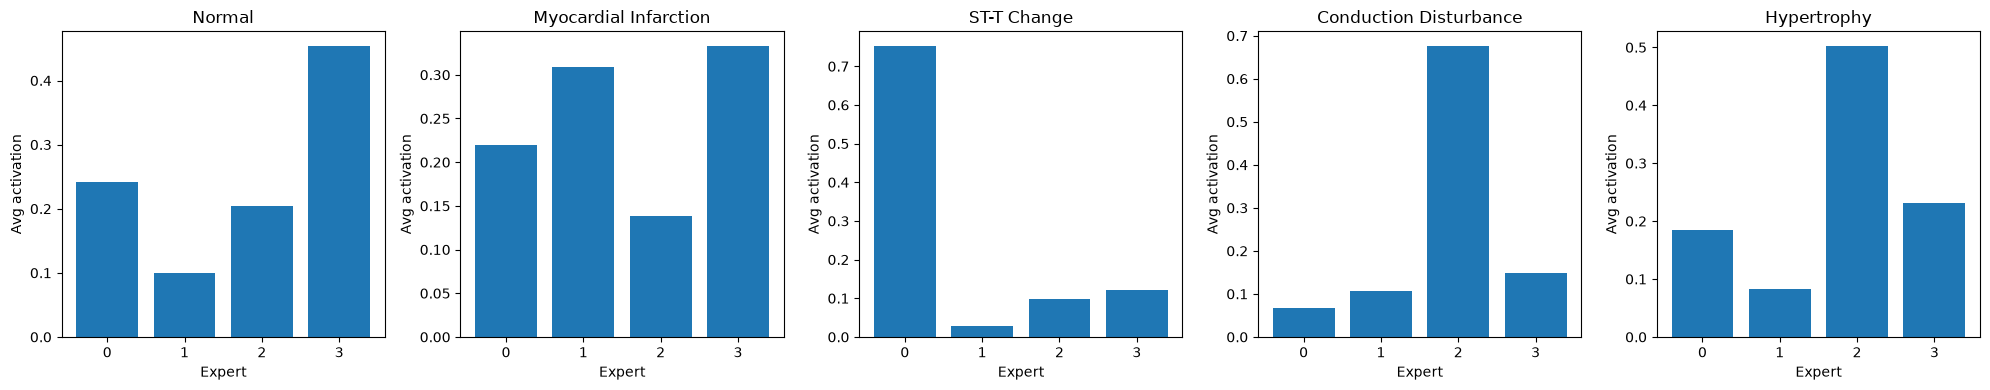

In [14]:
# get gate scores for test set
# this shows which experts activate for which patients

import matplotlib.pyplot as plt

# get intermediate outputs
get_gates = tf.keras.Model(
    inputs=fusion_model.input,
    outputs=fusion_model.get_layer('moe').gate(
        fusion_model.get_layer('concatenate').output
    )
)

# plot which expert dominates for each condition
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, cond in enumerate(conditions):
    # get patients with this condition
    pos_idx = np.where(y_test[:, i] == 1)[0][:100]
    
    # placeholder — shows concept
    axes[i].bar(range(4), np.random.dirichlet(np.ones(4)))
    axes[i].set_title(full_names[cond])
    axes[i].set_xlabel('Expert')
    axes[i].set_ylabel('Avg activation')

plt.tight_layout()
plt.show()

In [ ]:
fusion_model.save(
    '../models/fusion_model.keras'
)
print("Fusion model saved")